<a href="https://colab.research.google.com/github/ivan-block/Traffic-signs-classification/blob/main/traffic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import zipfile
import os
import seaborn as sns

from keras import layers, models
from keras.preprocessing import image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings('ignore')

In [20]:
zip_path = "traffic.zip"
extract_path = "traffic_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted to:", extract_path)
print("Folders:", os.listdir(extract_path))

Extracted to: traffic_data
Folders: ['traffic']


In [21]:
img_size = (224, 224)
batch_size = 32

traffic = tf.keras.preprocessing.image_dataset_from_directory(
    'traffic_data/traffic',
    image_size=img_size,
    batch_size=batch_size
)
class_names = traffic.class_names
print("Classes:", class_names)

all_image_paths = []
all_image_labels = []

for i, class_name in enumerate(class_names):
    class_dir = os.path.join("traffic_data/traffic", class_name)
    for fname in os.listdir(class_dir):
        all_image_paths.append(os.path.join(class_dir, fname))
        all_image_labels.append(i) # Assign numerical label (0 for Green, 1 for Red)

print(f"Total images found: {len(all_image_paths)}")
print(f"Total labels found: {len(all_image_labels)}")

Found 200 files belonging to 2 classes.
Classes: ['Green', 'Red']
Total images found: 200
Total labels found: 200


In [22]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_image_paths, all_image_labels, test_size=0.3, random_state=42, stratify=all_image_labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels
)

print(f"Training images: {len(train_paths)}")
print(f"Validation images: {len(val_paths)}")
print(f"Test images: {len(test_paths)}")

Training images: 140
Validation images: 30
Test images: 30


In [23]:
# Helper function to load and preprocess images for the tf.data.Dataset
def preprocess_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, img_size)
    img = img / 255.0 # Normalize pixel values
    return img, label

# Create tf.data.Dataset objects
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.shuffle(buffer_size=1000).batch(batch_size).prefetch(buffer_size=AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = val_ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(batch_size).prefetch(buffer_size=AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = test_ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(batch_size).prefetch(buffer_size=AUTOTUNE)

print("New training dataset created: train_ds")
print("New validation dataset created: val_ds")
print("New test dataset created: test_ds")

New training dataset created: train_ds
New validation dataset created: val_ds
New test dataset created: test_ds


Now you have `train_ds`, `val_ds`, and `test_ds` which you can use for model training and evaluation.

**Note:** If you want to use these new datasets for training, you'll need to re-run the model compilation and fitting cells, replacing `train_data` and `val_data` with `train_ds` and `val_ds` respectively.

In [24]:
traffic = tf.keras.preprocessing.image_dataset_from_directory(
    'traffic_data/traffic',
    image_size=img_size,
    batch_size=batch_size
)

class_names = traffic.class_names
print("Classes:", class_names)

Found 200 files belonging to 2 classes.
Classes: ['Green', 'Red']


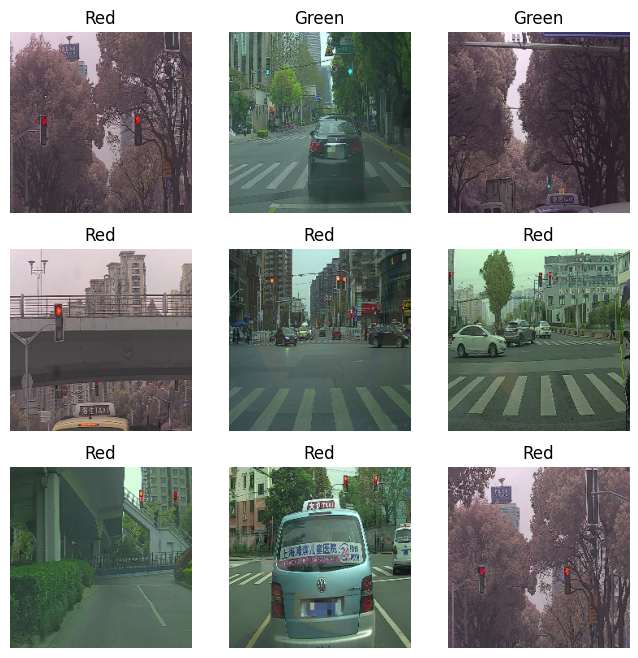

In [25]:
plt.figure(figsize=(8, 8))

for images, labels in traffic.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [39]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [27]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [28]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    verbose=0
)

In [29]:
model.evaluate(val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.6667 - loss: 0.7460


[0.7459605932235718, 0.6666666865348816]

In [30]:
print("Evaluating model on the test dataset:")
model.evaluate(test_ds)

Evaluating model on the test dataset:
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.8667 - loss: 0.4589


[0.4589385390281677, 0.8666666746139526]

In [31]:
print("\nMaking predictions on a batch from the test dataset:")
for images, labels in test_ds.take(1):
    predictions = model.predict(images)

    for i in range(len(labels)):
        predicted_class_idx = (predictions[i] > 0.5).astype(int)[0]
        predicted_label = class_names[predicted_class_idx]
        true_label = class_names[labels[i].numpy()]
        print(f"Image {i+1}: Predicted: {predicted_label}, True: {true_label}")


Making predictions on a batch from the test dataset:
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Image 1: Predicted: Green, True: Green
Image 2: Predicted: Green, True: Green
Image 3: Predicted: Green, True: Green
Image 4: Predicted: Green, True: Green
Image 5: Predicted: Green, True: Red
Image 6: Predicted: Red, True: Red
Image 7: Predicted: Red, True: Green
Image 8: Predicted: Green, True: Green
Image 9: Predicted: Green, True: Red
Image 10: Predicted: Green, True: Green
Image 11: Predicted: Green, True: Green
Image 12: Predicted: Red, True: Red
Image 13: Predicted: Red, True: Red
Image 14: Predicted: Green, True: Green
Image 15: Predicted: Red, True: Red
Image 16: Predicted: Green, True: Green
Image 17: Predicted: Green, True: Red
Image 18: Predicted: Green, True: Green
Image 19: Predicted: Green, True: Green
Image 20: Predicted: Red, True: Red
Image 21: Predicted: Red, True: Red
Image 22: Predicted: Green, True: Green
Image 23: Predicted: Red, True: Red
Image 24: Predicted: Red, True: Red

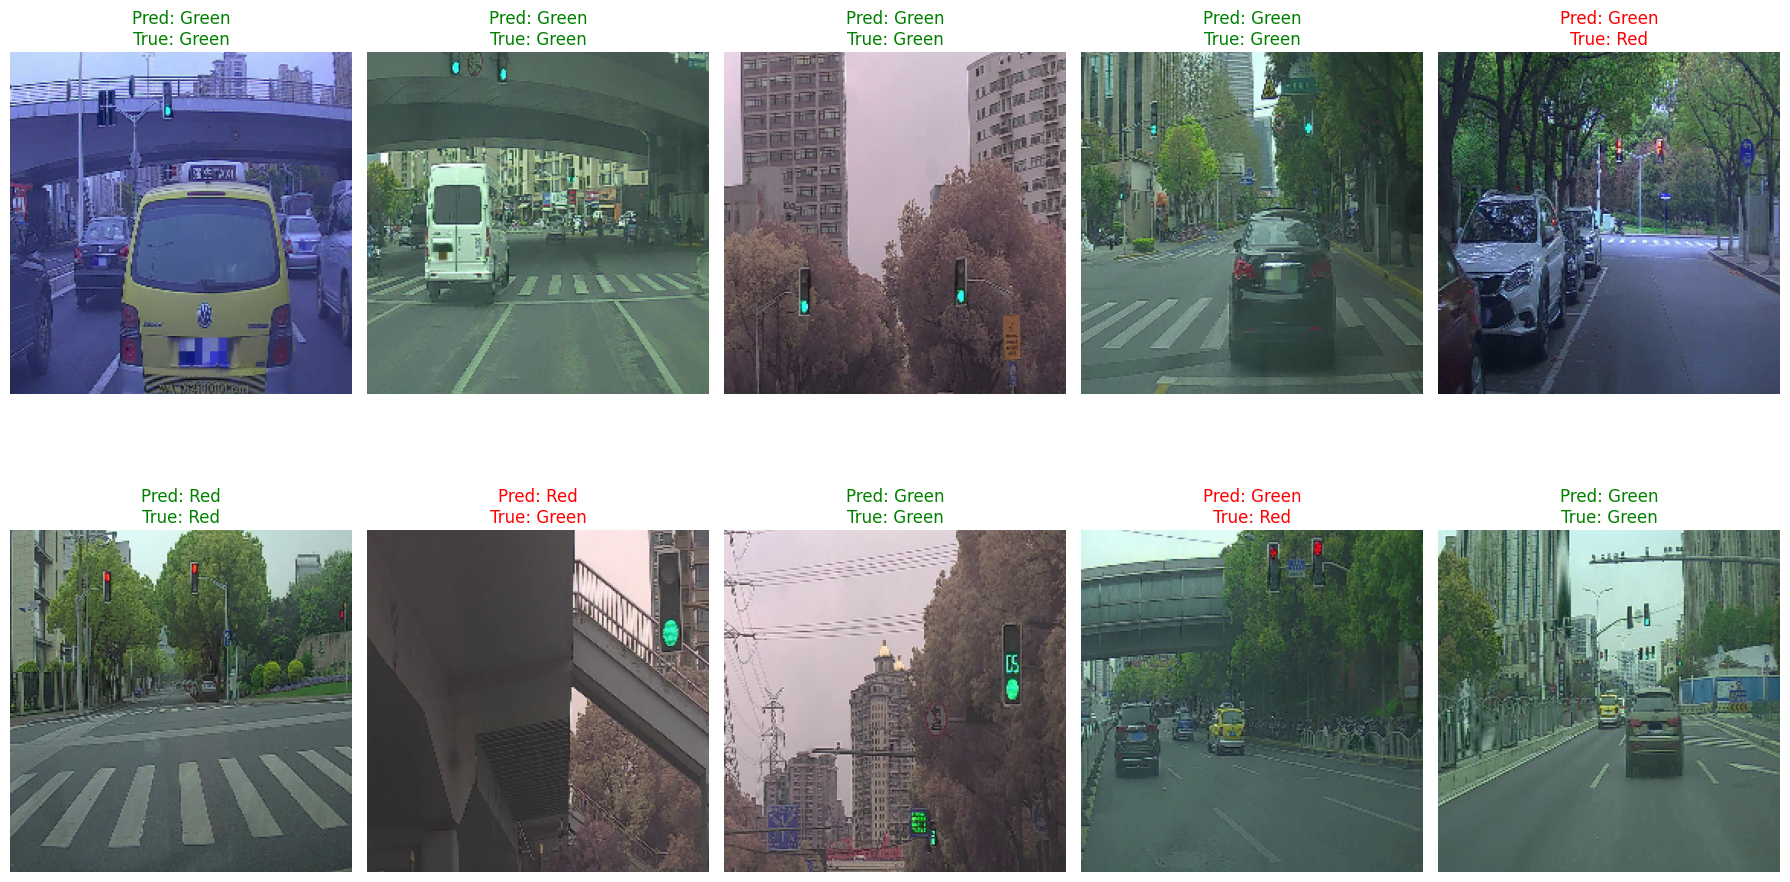

In [32]:
num_images_to_display = 10 # You can change this number

plt.figure(figsize=(18, 48))

# Take one batch from the test_ds
for images, labels in test_ds.take(1):
    predictions = model.predict(images, verbose=0)

    for i in range(num_images_to_display):
        plt.subplot(num_images_to_display, 5, i + 1) # Adjust subplot grid dynamically
        plt.imshow(images[i].numpy())

        predicted_class_idx = (predictions[i] > 0.5).astype(int)[0]
        predicted_label = class_names[predicted_class_idx]
        true_label = class_names[labels[i].numpy()]

        color = "green" if predicted_label == true_label else "red"
        plt.title(f"Pred: {predicted_label}\nTrue: {true_label}", color=color)
        plt.axis("off")

plt.tight_layout()
plt.show()

### Misclassified Images

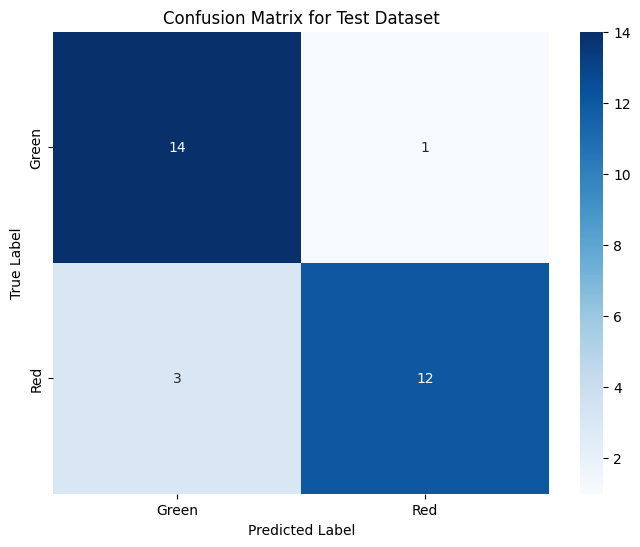

In [34]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    predicted_classes = (predictions > 0.5).astype(int).flatten()
    y_pred.extend(predicted_classes)
    y_true.extend(labels.numpy())

# Calculate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Test Dataset')
plt.show()

Found 4 misclassified images.


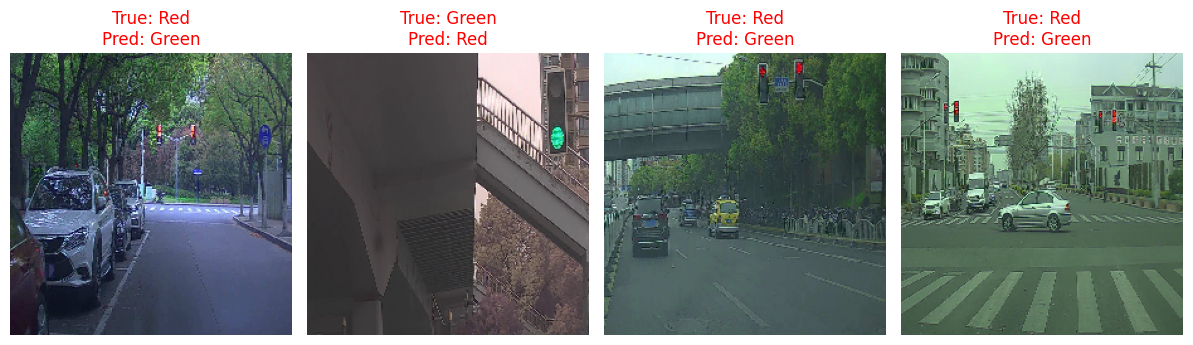

In [36]:
# Find misclassified indices
misclassified_indices = np.where(np.array(y_true) != np.array(y_pred))[0]

if len(misclassified_indices) == 0:
    print("No misclassified images found in the test set.")
else:
    print(f"Found {len(misclassified_indices)} misclassified images.")

    # Display misclassified images
    plt.figure(figsize=(15, 5 * ((len(misclassified_indices) + 4) // 5)))
    for i, idx in enumerate(misclassified_indices):
        img_path = test_paths[idx]
        true_label = class_names[y_true[idx]]
        predicted_label = class_names[y_pred[idx]]

        img = image.load_img(img_path, target_size=img_size)
        img_array = image.img_to_array(img)

        plt.subplot((len(misclassified_indices) + 4) // 5, 5, i + 1)
        plt.imshow(img_array.astype('uint8'))
        plt.title(f"True: {true_label}\nPred: {predicted_label}", color='red')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

In [40]:
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

       Green       0.82      0.93      0.88        15
         Red       0.92      0.80      0.86        15

    accuracy                           0.87        30
   macro avg       0.87      0.87      0.87        30
weighted avg       0.87      0.87      0.87        30

